In [1]:
from pathlib import Path
import pandas as pd
import torch
import matplotlib.pyplot as plt
import xarray as xr
import yaml
import geopandas as gpd
import numpy as np
import pickle
from neuralhydrology.evaluation.metrics import calculate_all_metrics
from neuralhydrology.evaluation.metrics import calculate_metrics
from neuralhydrology.evaluation.metrics import missed_peaks
import neuralhydrology

from recession import sig_BaseflowRecessionK, util_DataCheck, util_RecessionSegments, util_MasterRecessionCurve

In [2]:
# ------------------- Paths -------------------
RUN_DIR = Path("../runs") #Uruguay
# RUN_DIR = Path("../extending_caravan/runs") #USA

# Ensemble metrics

In [3]:
# URUGUAY

run_pattern = "precip_prcp_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_seed_*"
# run_pattern = "precip_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_seed_*" 
# run_pattern = "precip_prcp_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*" 
# run_pattern = "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*" 
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*" 

matched_paths = sorted(RUN_DIR.glob(f"{run_pattern}/validation/model_epoch030/validation_results.p"))
print(f"Found {len(matched_paths)} runs: {[p.parts[-4] for p in matched_paths]}")

Found 8 runs: ['precip_prcp_mm_day_seed_111_2202_184533', 'precip_prcp_mm_day_seed_222_2202_185112', 'precip_prcp_mm_day_seed_333_2202_185649', 'precip_prcp_mm_day_seed_444_2202_190226', 'precip_prcp_mm_day_seed_555_2302_064058', 'precip_prcp_mm_day_seed_666_2302_064647', 'precip_prcp_mm_day_seed_777_2302_065235', 'precip_prcp_mm_day_seed_888_2302_065823']


In [4]:
# Load all runs
all_runs_data = []
for file_path in matched_paths:
    with open(file_path, "rb") as f:
        all_runs_data.append(pickle.load(f))

# Average the simulated flows across seeds, per basin
ensemble_data = {}

for basin_id in all_runs_data[0].keys():
    # Stack simulated flows from all seeds: shape (n_seeds, n_timesteps, time_step)
    sims = np.stack([
        run[basin_id]['1D']['xr']['QObs_mm_d_sim'].values #['QObs(mm/d)_sim'].values 
        for run in all_runs_data
    ], axis=0)
    
    mean_sim = np.mean(sims, axis=0)  # Average across seeds
    mean_sim[mean_sim < 0] = np.nan # remove negative values (because then I can't fit the log(Q))
    
    # Copy structure from first run, replace sim with ensemble mean
    xr_ensemble = all_runs_data[0][basin_id]['1D']['xr'].copy()
    xr_ensemble['QObs_mm_d_sim'].values[:] = mean_sim #['QObs(mm/d)_sim'].values[:] = mean_sim #
    
    ensemble_data[basin_id] = {'1D': {'xr': xr_ensemble}}

ensemble_data

{'CAMELS_UY_10': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date           (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
     * time_step      (time_step) int64 8B 0
   Data variables:
       QObs_mm_d_obs  (date, time_step) float32 15kB 0.09307 0.1167 ... 0.09939
       QObs_mm_d_sim  (date, time_step) float32 15kB 0.5385 0.4731 ... 0.4858}},
 'CAMELS_UY_11': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date           (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
     * time_step      (time_step) int64 8B 0
   Data variables:
       QObs_mm_d_obs  (date, time_step) float32 15kB 0.263 0.2622 ... 0.4166 0.4053
       QObs_mm_d_sim  (date, time_step) float32 15kB 0.6404 0.5621 ... 0.5564}},
 'CAMELS_UY_15': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date           (d

In [5]:
ds = ensemble_data['CAMELS_UY_6']['1D']['xr']
ds

<xarray.Dataset> Size: 58kB
Dimensions:        (date: 3652, time_step: 1)
Coordinates:
  * date           (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
  * time_step      (time_step) int64 8B 0
Data variables:
    QObs_mm_d_obs  (date, time_step) float32 15kB 0.2257 0.2025 ... 0.2723
    QObs_mm_d_sim  (date, time_step) float32 15kB 0.628 0.5523 ... 0.4464 0.4742

In [6]:
basin = "CAMELS_UY_6"

In [7]:
# # Prepare inputs
# Q = ds['QObs_mm_d_obs'].values.squeeze().astype(float)  # (3652,)
# t = ds['date'].values                                    # datetime64[ns]

import numpy as np
from recession import sig_BaseflowRecessionK

ds = ensemble_data[basin]['1D']['xr']
t = ds['date'].values

for var, label in [('QObs_mm_d_obs', 'Observed'), ('QObs_mm_d_sim', 'Simulated')]:
    Q = ds[var].values.squeeze().astype(float)
    K, error_flag, error_str = sig_BaseflowRecessionK(Q, t)
    
    print(f"\n--- {label} ---")
    print(f"BaseflowRecessionK (K): {K:.4f}")
    print(f"error_flag:             {error_flag}")
    print(f"error_str:              {error_str}")
    
    if not np.isnan(K):
        if K < 0.065:
            print("-> Groundwater-dominated, slow-draining system")
        else:
            print("-> Shallow subsurface flow dominated, fast-draining system")


--- Observed ---
BaseflowRecessionK (K): 0.1723
error_flag:             1
error_str:              Warning: Ignoring NaNs in streamflow data. 
-> Shallow subsurface flow dominated, fast-draining system

--- Simulated ---
BaseflowRecessionK (K): 0.1193
error_flag:             0
error_str:              
-> Shallow subsurface flow dominated, fast-draining system


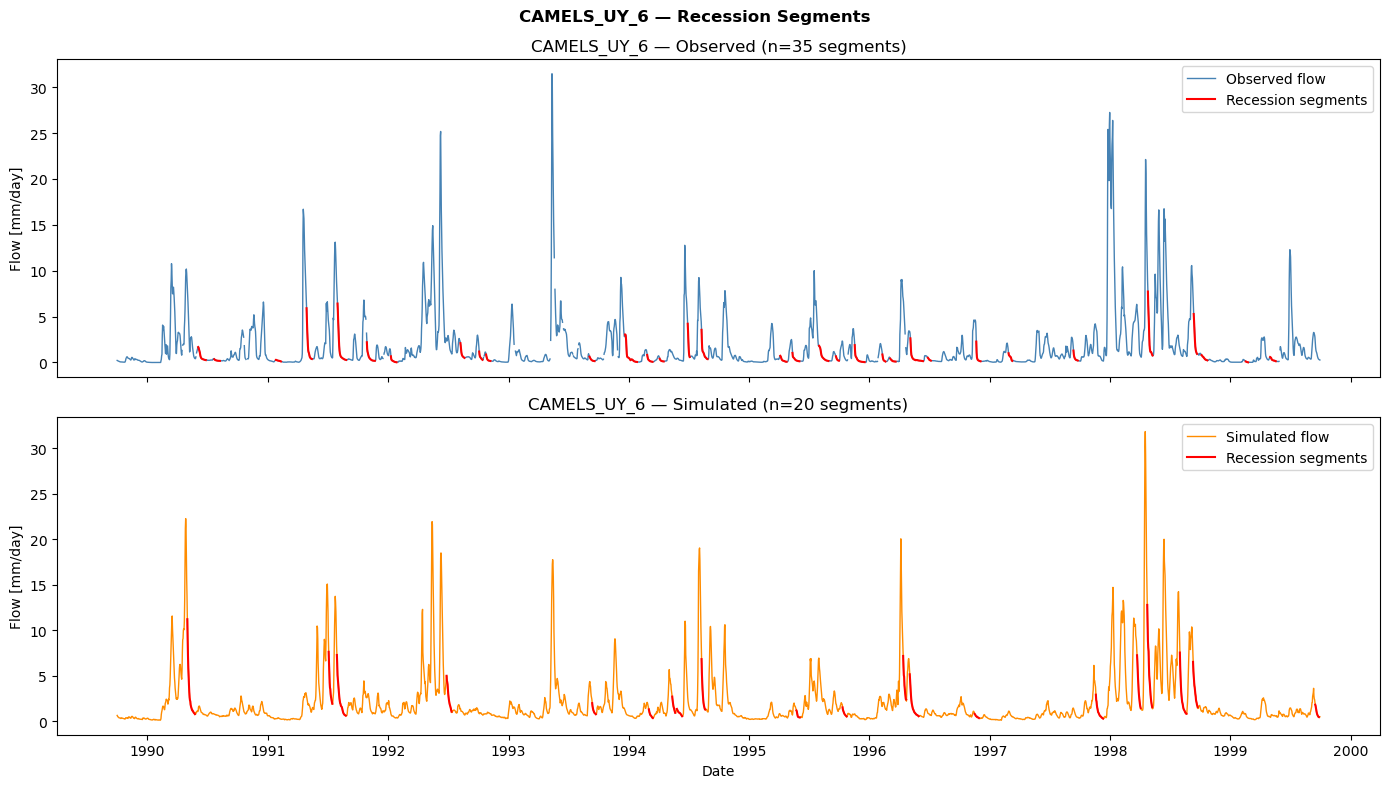

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (var, label, color) in zip(axes, [
    ('QObs_mm_d_obs', 'Observed',  'steelblue'),
    ('QObs_mm_d_sim', 'Simulated', 'darkorange')
]):
    Q = ds[var].values.squeeze().astype(float)

    # DataCheck and recession segments
    _, _, _, t_clean = util_DataCheck(Q, t)
    flow_section, _, _ = util_RecessionSegments(
        Q, t_clean,
        recession_length=15,
        start_of_recession='baseflow',
        filter_par=0.925
    )

    # Full streamflow
    ax.plot(t_clean, Q, color=color, linewidth=1, label=f'{label} flow')

    # Recession segments
    for i, (start, end) in enumerate(flow_section):
        ax.plot(t_clean[start:end+1], Q[start:end+1],
                color='red', linewidth=1.5,
                label='Recession segments' if i == 0 else None)

    ax.set_ylabel('Flow [mm/day]')
    ax.set_title(f'{basin} — {label} (n={len(flow_section)} segments)')
    ax.legend()

axes[-1].set_xlabel('Date')
plt.suptitle(f'{basin} — Recession Segments', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# # After computing MRC
# MRC, lags, seg_indices, segments_aligned = util_MasterRecessionCurve(
#     Q, flow_section, fit_method='nonparametric_analytic', match_method='log'
# )

# fig, ax = plt.subplots(figsize=(7, 5))
# ax.set_yscale('log')

# # Plot each recession segment shifted by its lag
# for i, seg in enumerate(segments_aligned):
#     t_seg = np.arange(len(seg)) + lags[i]  # shift by lag
#     ax.plot(t_seg, seg, color='steelblue', alpha=0.4, linewidth=1)

# # Plot fitted MRC
# mrc_t = MRC[:, 0]
# mrc_q = MRC[:, 1]
# valid = mrc_q > 0
# A = np.column_stack([np.ones(valid.sum()), mrc_t[valid]])
# mdl, _, _, _ = np.linalg.lstsq(A, np.log(mrc_q[valid]), rcond=None)
# K = -mdl[1]
# t_fit = np.linspace(mrc_t.min(), mrc_t.max(), 200)
# ax.plot(t_fit, np.exp(mdl[0] + mdl[1] * t_fit), 'r-', linewidth=2,
#         label=f'Fitted curve (K={K:.4f})')

# ax.set_xlabel('Relative time [days]')
# ax.set_ylabel('Flow [mm/day]')
# ax.legend()
# plt.tight_layout()
# plt.show()

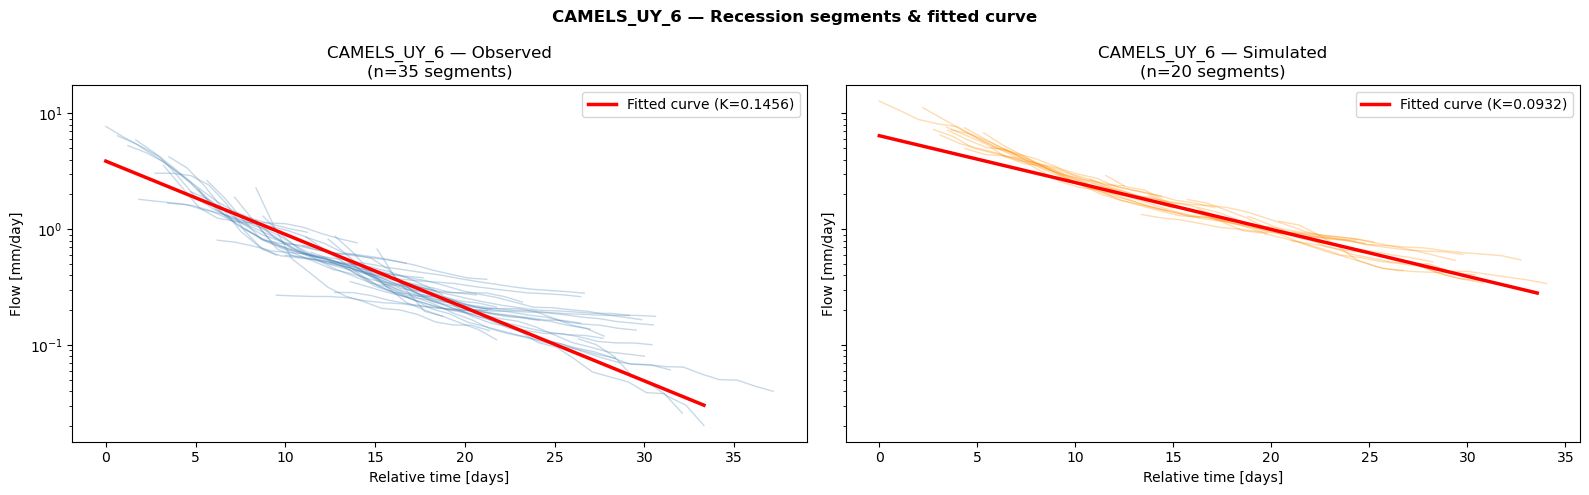

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (var, label, color) in zip(axes, [
    ('QObs_mm_d_obs', 'Observed',  'steelblue'),
    ('QObs_mm_d_sim', 'Simulated', 'darkorange')
]):
    Q = ds[var].values.squeeze().astype(float)

    # DataCheck and recession segments
    _, _, _, t_clean = util_DataCheck(Q, t)
    flow_section, _, _ = util_RecessionSegments(
        Q, t_clean,
        recession_length=15,
        start_of_recession='baseflow',
        filter_par=0.925
    )

    # Build MRC — unpack all 4 return values
    MRC, lags, seg_indices, segments_aligned = util_MasterRecessionCurve(
        Q, flow_section, match_method='log'
    )

    # Plot individual segments shifted by their lag
    for i, seg in enumerate(segments_aligned):
        t_seg = np.arange(1, len(seg) + 1) + lags[i]  # 1-based + lag, matching MATLAB
        ax.plot(t_seg, seg, color=color, alpha=0.3, linewidth=1)

    # Fit log-linear: log(Q) = a + b*t  =>  K = -b
    mrc_t = MRC[:, 0]
    mrc_q = MRC[:, 1]

    # valid = mrc_q > 0

    fit_start_time = 15.0  # <-- change this to whatever day you want
    valid = (mrc_q > 0) & (mrc_t >= fit_start_time)

    A = np.column_stack([np.ones(valid.sum()), mrc_t[valid]])
    mdl, _, _, _ = np.linalg.lstsq(A, np.log(mrc_q[valid]), rcond=None)
    K = -mdl[1]

    # Plot fitted curve
    t_fit = np.linspace(mrc_t.min(), mrc_t.max(), 300)
    q_fit = np.exp(mdl[0] + mdl[1] * t_fit)
    ax.plot(t_fit, q_fit, color='red', linewidth=2.5,
            label=f'Fitted curve (K={K:.4f})')

    ax.set_yscale('log')  # set per axis, not just the last one
    ax.set_xlabel('Relative time [days]')
    ax.set_ylabel('Flow [mm/day]')
    ax.set_title(f'CAMELS_UY_6 — {label}\n(n={len(flow_section)} segments)')
    ax.legend()

plt.suptitle(f'{basin} — Recession segments & fitted curve', fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Define all run patterns you want to compare
run_patterns = {
    "caravan":        "precip_prcp_mm_day_seed_*",
    "chirps":         "precip_prcp_chirps_mm_day_seed_*",
    "mswep":          "precip_prcp_mswep_mm_day_seed_*",
    "gauge":          "precip_prcp_gauge_mm_day_seed_*",
    "chirps+mswep":   "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_seed_*",
    "chirps+mswep+gauge": "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*",
    "caravan+chirps+mswep+gauge": "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*"
}

def load_ensemble(pattern):
    """Load and average across seeds for a given run pattern."""
    matched_paths = sorted(RUN_DIR.glob(f"{pattern}/validation/model_epoch030/validation_results.p"))
    if not matched_paths:
        return None
    
    all_runs_data = []
    for file_path in matched_paths:
        with open(file_path, "rb") as f:
            all_runs_data.append(pickle.load(f))
    
    ensemble_data = {}
    for basin_id in all_runs_data[0].keys():
        sims = np.stack([
            run[basin_id]['1D']['xr']['QObs_mm_d_sim'].values
            for run in all_runs_data
        ], axis=0)
        mean_sim = np.mean(sims, axis=0)
        mean_sim[mean_sim < 0] = np.nan

        xr_ensemble = all_runs_data[0][basin_id]['1D']['xr'].copy()
        xr_ensemble['QObs_mm_d_sim'].values[:] = mean_sim
        ensemble_data[basin_id] = {'1D': {'xr': xr_ensemble}}
    
    return ensemble_data

def compute_K(Q, t):
    """Safe wrapper around sig_BaseflowRecessionK."""
    K, error_flag, error_str = sig_BaseflowRecessionK(Q, t)
    return K  # returns nan if error

# ── Main loop ──────────────────────────────────────────────────────────────────
all_records = {}

# First pass: compute K_obs once per basin
print("Computing K_obs (observations)...")
first_pattern = next(iter(run_patterns.values()))
first_ensemble = load_ensemble(first_pattern)
for basin_id, basin_data in first_ensemble.items():
    ds = basin_data['1D']['xr']
    t = ds['date'].values
    Q_obs = ds['QObs_mm_d_obs'].values.squeeze().astype(float)
    all_records[basin_id] = {'K_obs': compute_K(Q_obs, t)}

# Second pass: compute K_sim for every pattern
for label, pattern in run_patterns.items():
    print(f"Processing pattern: {label} ...")
    ensemble = load_ensemble(pattern)
    
    if ensemble is None:
        print(f"  -> No runs found, skipping.")
        for basin_id in all_records:
            all_records[basin_id][f'K_{label}'] = np.nan
        continue
    
    for basin_id, basin_data in ensemble.items():
        ds = basin_data['1D']['xr']
        t = ds['date'].values
        Q_sim = ds['QObs_mm_d_sim'].values.squeeze().astype(float)
        all_records[basin_id][f'K_{label}'] = compute_K(Q_sim, t)

# ── Build DataFrame ────────────────────────────────────────────────────────────
df_K = pd.DataFrame.from_dict(all_records, orient='index')
df_K.index.name = 'basin_id'
col_order = ['K_obs'] + [f'K_{label}' for label in run_patterns]
df_K = df_K[col_order]

pd.options.display.float_format = '{:.3f}'.format
df_K

Computing K_obs (observations)...
Processing pattern: caravan ...
Processing pattern: chirps ...
Processing pattern: mswep ...
Processing pattern: gauge ...
Processing pattern: chirps+mswep ...
Processing pattern: chirps+mswep+gauge ...
Processing pattern: caravan+chirps+mswep+gauge ...


,K_obs,K_caravan,K_chirps,K_mswep,K_gauge,K_chirps+mswep,K_chirps+mswep+gauge,K_caravan+chirps+mswep+gauge
basin_id,,,,,,,,
CAMELS_UY_10,0.169,0.115,0.123,0.136,0.118,0.114,0.100,0.147
CAMELS_UY_11,0.060,0.133,0.120,0.120,0.140,0.106,0.150,0.139
CAMELS_UY_15,0.257,NaN,0.126,NaN,0.156,0.115,0.195,0.135
CAMELS_UY_16,0.228,NaN,NaN,NaN,NaN,0.121,0.239,0.162
CAMELS_UY_2,0.183,0.128,0.141,0.140,0.134,0.145,0.136,0.162
CAMELS_UY_3,0.160,0.129,0.151,0.155,0.146,0.165,0.139,0.164
CAMELS_UY_5,0.189,0.170,0.213,0.211,0.175,0.193,0.198,0.251
CAMELS_UY_6,0.172,0.119,0.139,0.136,0.117,0.140,0.111,0.139
CAMELS_UY_7,0.210,0.174,0.180,0.233,0.165,0.181,0.213,0.198


In [12]:
df_K.median()


K_obs                          0.182
K_caravan                      0.129
K_chirps                       0.140
K_mswep                        0.140
K_gauge                        0.143
K_chirps+mswep                 0.140
K_chirps+mswep+gauge           0.150
K_caravan+chirps+mswep+gauge   0.162
dtype: float64